# Cancer Genomics Pipeline: Finding Cancer Mutations from DNA Sequencing Data

## What this project does

Cancer is a disease of the genome, which means it is caused by changes (called mutations) in the DNA inside our cells. This project reads the DNA of cancer cells and the DNA of matched healthy cells from the same person, compares them, and finds the mutations that are present only in the cancer. Those cancer only mutations are called "somatic" mutations, and finding them is a core task in cancer research and in modern cancer medicine.

## Why it matters

Knowing exactly which mutations a tumor carries helps researchers understand how the cancer grew, and helps doctors choose treatments that target those specific mutations. This kind of analysis is the foundation of "precision oncology", meaning cancer care that is tailored to the individual tumor. The methods used here follow the widely used GATK Best Practices for somatic mutation discovery from the Broad Institute ([GATK](https://gatk.broadinstitute.org/)).

## The project has two parts

**Project 1, the Automated Somatic SNV Pipeline.** This takes paired tumor and normal (healthy) DNA sequencing files, aligns them to the human reference genome (GRCh38) using a tool called BWA-MEM, processes the aligned files with a tool called Samtools, and identifies cancer specific single letter mutations (called somatic SNVs) using GATK Mutect2. The whole workflow is automated with a tool called Snakemake so it runs by itself from raw files to final results.

**Project 2, the Containerized Cancer QC Parsing Engine.** This builds on Project 1 by scaling it up to handle several tumor and normal patient pairs at once. It then uses a Python data analysis script to calculate three important cancer measurements from the results: Variant Allele Frequency (VAF), Tumor Mutational Burden (TMB), and target exon coverage depth. Finally, the whole system is packaged into a Docker container so it runs the same way on any computer.


## Data Sources (full citations)

All input files used in this project are public. Here is exactly where each file came from.

**HCC1143 tumor and HCC1143BL matched normal (aligned BAM files).** These come from the GATK Best Practices public data for somatic analysis on the human reference GRCh38 ([gatk-best-practices/somatic-hg38](https://console.cloud.google.com/storage/browser/gatk-best-practices/somatic-hg38)). HCC1143 is a well studied breast cancer cell line, and HCC1143BL is a healthy blood sample from the same patient.

**HCC1954 tumor and HCC1954BL matched normal (raw FASTQ files).** These come from 10x Genomics public whole exome datasets: the tumor sample ([HCC1954 tumor whole exome](https://www.10xgenomics.com/datasets/hcc-1954-tumor-whole-exome-1-standard-2-0-0)) and the matched normal sample ([HCC1954 normal whole exome](https://www.10xgenomics.com/datasets/hcc-1954-normal-whole-exome-1-standard-2-0-0)).

**Human reference genome (GRCh38) and the helper resource files.** The reference genome, its index files, and the somatic resource files (Panel of Normals, gnomAD germline frequencies, and the ExAC common variants file) come from two public Google Cloud buckets maintained by the Broad Institute: the reference bucket ([gcp-public-data--broad-references/hg38/v0](https://console.cloud.google.com/storage/browser/gcp-public-data--broad-references/hg38/v0)) and the somatic best practices bucket ([gatk-best-practices/somatic-hg38](https://console.cloud.google.com/storage/browser/gatk-best-practices/somatic-hg38)).


## Two starting points: one pair is raw, one pair is already aligned

An important teaching feature of this project is that the two sample pairs start at different stages, which lets us show two situations you meet in real work.

**HCC1954 starts as raw FASTQ files.** FASTQ is the raw text output that comes straight off a DNA sequencing machine, before any processing. Because this pair is raw, we run the full pipeline on it: quality checking, alignment to the reference genome, sorting, duplicate marking, quality recalibration, and only then mutation calling. This makes HCC1954 the better teaching example, because you see every step of the pipeline from the very beginning.

**HCC1143 starts as aligned BAM files.** BAM is the file format you get after the raw reads have already been lined up against the reference genome. Because this pair is already aligned, we skip the alignment steps and go straight to mutation calling. This shows the common real world situation where someone hands you data that is already partly processed, and you continue from there.

In short, HCC1954 demonstrates the complete "from scratch" workflow, while HCC1143 demonstrates how to work with pre aligned data. Both pairs finish at the same place: a clean list of the tumor's somatic mutations.


# Background Concepts

## DNA sequencing and the FASTQ file

DNA is a long chain built from four chemical "letters": A, C, G, and T. The exact order of these letters is the instruction manual for building and running a living thing. "DNA sequencing" is the laboratory process of reading that order of letters from a sample.

Modern machines cannot read a whole chromosome in one go. Instead they read millions of short fragments, each roughly 100 to 150 letters long, and each short fragment is called a "read". A FASTQ file is the plain text file that stores all these reads, and for each read it also stores a quality score for every letter that says how confident the machine was about that letter ([FASTQ format](https://en.wikipedia.org/wiki/FASTQ_format)).

## The reference genome, and why we align reads to it

A reference genome is a high quality, agreed upon "master copy" of the human DNA sequence that the whole scientific community uses as a common map. The version used here is called GRCh38, also written as hg38 ([Genome Reference Consortium](https://www.ncbi.nlm.nih.gov/grc)). Think of it as the picture on the front of a jigsaw puzzle box.

Our millions of short reads are like puzzle pieces with no picture printed on them. "Aligning" means figuring out where along the reference genome each short read belongs, by matching its letters to the map. Once we know where every read sits, we can spot where our sample differs from the reference, and those differences are the candidate mutations.

## BWA-MEM and what "alignment" means

BWA-MEM is the specific software tool we use to do the alignment, which means it takes each short read and finds its best matching location on the reference genome ([BWA](https://github.com/lh3/bwa), method described in [Li 2013](https://arxiv.org/abs/1303.3997)). It is fast and accurate, and it is a standard first step in most DNA analysis.

The "MEM" part is simply the name of the algorithm it uses. The output of alignment is a file that records, for every read, which chromosome and which position it matched.

## The BAM file and Samtools

When alignment results are first produced they are in a text format called SAM. A BAM file is simply the compressed, computer friendly version of that same information, which saves a lot of disk space and is much faster for programs to read ([HTSlib and Samtools](http://www.htslib.org/)).

Samtools is a toolbox for working with these BAM files. In this project we use it to sort reads into genome order, to build an index (like a table of contents that lets software jump instantly to any position), and to inspect the aligned reads.


## Somatic mutation versus germline mutation

A "germline" mutation is a DNA change you were born with, present in every cell of your body, including inherited traits. A "somatic" mutation is a change that appears later, in one cell during your lifetime, and is then copied into that cell's descendants ([NCI genetics dictionary](https://www.cancer.gov/publications/dictionaries/genetics-dictionary)). Cancer is driven by somatic mutations.

The trick this project uses is comparison. By sequencing both the tumor and a healthy (normal) sample from the same person, we can subtract everything the person was born with (the germline), and what remains are the tumor only (somatic) mutations. This is exactly why the samples come in tumor and normal pairs.

## SNV, a single letter change

SNV stands for Single Nucleotide Variant, which is a change in exactly one DNA letter, for example an A where the reference has a G. It is the smallest possible kind of mutation, like a single typo in a book. Many important cancer mutations are SNVs, which is why this pipeline focuses on finding them.

## CNV, and how it differs from an SNV

CNV stands for Copy Number Variant. Instead of changing a single letter, a CNV is when a large chunk of DNA is duplicated (too many copies) or deleted (too few copies) ([NCI genetics dictionary](https://www.cancer.gov/publications/dictionaries/genetics-dictionary)). If an SNV is a single typo, a CNV is a whole paragraph being copied several times or torn out of the book.

CNVs matter in cancer because gaining extra copies of a growth gene, or losing a protective gene, can drive the disease. Detecting CNVs uses different methods from SNV detection, so in this project CNV analysis is only an optional extension, and the two blacklist and panel resource files listed later support that optional CNV work.

## GATK Mutect2 and how it finds cancer mutations

Mutect2 is the tool from the GATK software package that is designed specifically to find somatic mutations in tumor samples ([GATK](https://gatk.broadinstitute.org/)). It looks at every position on the genome, counts how many reads support a change in the tumor, and checks whether that same change is absent in the matched normal.

Mutect2 uses a statistical model to separate real mutations from the noise that sequencing machines naturally produce. It also uses extra reference resources (described below) to avoid calling common inherited variants and known machine artifacts as if they were cancer mutations.

## The VCF file

VCF stands for Variant Call Format. It is the standard text file that lists the mutations that were found, one row per mutation, giving the chromosome, the position, the original letter, the new letter, and a set of quality measurements ([VCF specification](https://samtools.github.io/hts-specs/)). The final answer of the mutation calling step is a VCF file.

## Panel of Normals, reducing false positives

A "false positive" is when the software says there is a mutation but there really is not, often because of a repeated machine error. A Panel of Normals (PoN) is a file built from many healthy people's samples that records positions where these recurring errors and common artifacts tend to show up ([GATK somatic best practices](https://console.cloud.google.com/storage/browser/gatk-best-practices/somatic-hg38)).

By checking each candidate mutation against the Panel of Normals, Mutect2 can throw out changes that are really just common technical noise. This makes the final mutation list much cleaner and more trustworthy.


## Snakemake, and why we automate the pipeline

Running each tool by hand, one command at a time, is slow and easy to get wrong, especially when there are many steps and many samples. Snakemake is a "workflow manager", meaning software that runs all the steps for you in the correct order, automatically ([Snakemake](https://snakemake.readthedocs.io/)). You describe the steps once in a file called a Snakefile, and Snakemake figures out what to run.

Snakemake also only redoes work that is actually needed. If a step already finished and its inputs have not changed, Snakemake skips it, which saves a lot of time. This makes the whole analysis repeatable and much less error prone.

## Variant Allele Frequency (VAF)

VAF, short for Variant Allele Frequency, is the fraction of reads at a given position that show the mutation rather than the normal letter. For example, if 30 out of 100 reads show the mutation, the VAF is 0.30, or 30 percent. Biologically, VAF hints at what fraction of the tumor's cells carry that mutation, which helps tell early "trunk" mutations apart from later ones.

## Tumor Mutational Burden (TMB)

TMB, short for Tumor Mutational Burden, is a count of how many mutations a tumor has, usually expressed as mutations per million DNA letters (mutations per megabase) ([NCI cancer terms](https://www.cancer.gov/publications/dictionaries/cancer-terms)). It matters clinically because tumors with a high TMB tend to respond better to a type of treatment called immunotherapy, so TMB is used to help decide which patients may benefit ([NCI](https://www.cancer.gov/)). This is why measuring TMB is a valuable, clinically relevant output.

## Exon coverage depth, and why low coverage is a problem

An "exon" is one of the protein coding pieces of a gene, and whole exome sequencing focuses on reading these coding pieces. "Coverage depth" at a position is how many reads overlapped that position, so a depth of 100 means 100 reads covered it.

If coverage is too low, say only a handful of reads, we simply do not have enough evidence to trust any mutation call there, so real mutations can be missed. Checking coverage depth is therefore a basic quality control step that tells us which regions we can and cannot trust.

## pandas, for analyzing tables

pandas is a popular Python library (a ready made toolkit) for working with data arranged in tables of rows and columns, much like a programmable spreadsheet ([pandas](https://pandas.pydata.org/)). In Project 2 we use pandas to read the mutation and coverage results and to calculate VAF, TMB, and coverage depth. It makes summarizing and comparing samples straightforward.

## Docker and the Docker image

Docker is software that packages a program together with everything it needs to run, the exact tools, versions, and settings, into one self contained bundle ([Docker](https://www.docker.com/)). A "Docker image" is that bundle: a frozen snapshot you can copy to any computer. The classic analogy is a shipping container: no matter which ship, truck, or port it lands on, the container and its contents stay exactly the same.

## Why containerization matters for reproducible science

In science, other people must be able to repeat your analysis and get the same answer, otherwise the result cannot be trusted. Software is fragile, because a different version of a single tool can quietly change the output. By shipping the whole pipeline inside a Docker image, anyone can run it and get identical results no matter their operating system or setup, which is exactly what reproducible research requires ([Docker documentation](https://docs.docker.com/get-started/)).


# Environment Setup

## Important note for Windows users: where to actually run this

The specialized tools in this pipeline (BWA-MEM, Samtools, GATK4, and so on) are built for Linux and macOS and are installed through a system called Bioconda, which does not provide native Windows versions ([Bioconda](https://bioconda.github.io/)). Because your computer runs Windows, you have two reliable ways to run the command line steps below.

Option A is to use WSL2 (Windows Subsystem for Linux), a free Microsoft feature that runs a real Linux inside Windows, and then install the tools and launch Jupyter from there ([WSL documentation](https://learn.microsoft.com/windows/wsl/)). Option B, which this project is ultimately built around, is to run everything inside the Docker container described in the last section, because the container already carries a correct Linux setup with all tools installed. Either way, the commands themselves are identical.

The shell command cells below are written for the Linux style shell (called bash) that you get with both WSL2 and Docker. In Jupyter, a cell beginning with `%%bash` runs its whole contents in that shell, and a line beginning with `!` runs a single shell command.

## Creating the software environment with conda

The cell below creates one tidy "environment" (a private, self contained set of tools) named `cancer_genomics` and installs every tool the pipeline needs into it. Run this once, ideally in a terminal, then activate the environment and launch Jupyter from it, so that every cell in this notebook can see the tools.


In [ ]:
%%bash
# Create a new conda environment named "cancer_genomics" and install every tool into it.
# The two "-c" options tell conda which online catalogs (channels) to install from.
# The backslash \ at the end of a line just means "this command continues on the next line".
conda create -y -n cancer_genomics \
  -c conda-forge -c bioconda \
  python=3.10 \
  bwa \
  samtools \
  htslib \
  gatk4 \
  snakemake-minimal \
  picard \
  fastqc \
  mosdepth \
  pandas \
  matplotlib

# Turn the new environment on in your terminal BEFORE you start Jupyter:
#   conda activate cancer_genomics
#   jupyter notebook
# That way, all the tool commands in this notebook will be found.


## What each tool does

- **bwa**: lines up (aligns) the short DNA reads against the reference genome ([BWA](https://github.com/lh3/bwa)).
- **samtools**: sorts, indexes, and inspects the aligned BAM files ([Samtools](http://www.htslib.org/)).
- **htslib**: provides the helper programs `bgzip` and `tabix` that compress and index VCF files ([HTSlib](http://www.htslib.org/)).
- **gatk4**: the Broad Institute toolkit that includes Mutect2 for calling somatic mutations, plus the filtering tools ([GATK](https://gatk.broadinstitute.org/)).
- **snakemake-minimal**: runs all the steps automatically in the right order ([Snakemake](https://snakemake.readthedocs.io/)); the "minimal" build simply leaves out optional extras we do not need.
- **picard**: marks duplicate reads so they do not distort the results ([Picard](https://broadinstitute.github.io/picard/)).
- **fastqc**: produces an easy to read quality report for the raw FASTQ reads ([FastQC](https://www.bioinformatics.babraham.ac.uk/projects/fastqc/)).
- **mosdepth**: measures sequencing coverage depth quickly ([mosdepth](https://github.com/brentp/mosdepth)).
- **pandas** and **matplotlib**: analyze the results in tables and draw simple charts ([pandas](https://pandas.pydata.org/), [matplotlib](https://matplotlib.org/)).


# Data Inventory: confirm every file is present

Before running anything heavy, it is good practice to check that every input file actually exists where we expect it. The Python cell below looks for each file and prints a clear "PRESENT" or "MISSING" status. If anything is missing, fix that before continuing.

A few things about how your files are actually laid out on disk are worth knowing up front, because the pipeline is written to match them exactly:

- The three resource VCFs (Panel of Normals, gnomAD, and the ExAC common variants file) each sit inside their own subfolder, for example `1000g_pon.hg38.vcf/`. In this download they arrived UNcompressed and without a working index, so a one time preparation step further down compresses and indexes them into the `.vcf.gz` files the pipeline uses.
- The HCC1954 raw reads live inside a doubly nested folder, for example `HCC1954T_WES_210_fastqs/HCC1954T_WES_fastqs/`, and follow 10x Genomics naming. The real genomic reads are the `read-RA_*` files, while the `read-I1_*` files are short sample barcodes we ignore ([10x Genomics HCC1954 tumor WES](https://www.10xgenomics.com/datasets/hcc-1954-tumor-whole-exome-1-standard-2-0-0)).
- The HCC1143 normal BAM may have arrived named `somatic-hg38_hcc1143_N_clean.bam`, while its index uses the shorter name `hcc1143_N_clean.bam.bai`. The preparation step renames the BAM so the two match.


In [ ]:
# We use pathlib, a built in Python tool for handling file paths safely on any operating system.
from pathlib import Path

# PROJECT_DIR is the folder that holds all the data. On your Windows machine this is the path below.
# If you run this notebook inside WSL2 or Docker, that path will not exist, so we fall back to the
# folder Jupyter was started in.
PROJECT_DIR = Path(r"C:\Users\chuab\Desktop\cancer_genomics_pipeline_hcc1143_brca")
if not PROJECT_DIR.exists():
    PROJECT_DIR = Path.cwd()
print("Using project folder:", PROJECT_DIR)
print()

def find_first(*relative_paths):
    """Return the first of several possible file names that actually exists (or None)."""
    for rel in relative_paths:
        if (PROJECT_DIR / rel).exists():
            return rel
    return None

# Each entry: a human label, then one or more acceptable file names (we accept either the
# uncompressed OR the compressed/renamed form so this check passes before AND after preparation).
checks = [
    ("HCC1143 tumor BAM (pre-aligned)",        ["hcc1143_T_clean.bam"]),
    ("HCC1143 tumor BAM index",                ["hcc1143_T_clean.bam.bai"]),
    ("HCC1143 normal BAM (pre-aligned)",       ["hcc1143_N_clean.bam", "somatic-hg38_hcc1143_N_clean.bam"]),
    ("HCC1143 normal BAM index",               ["hcc1143_N_clean.bam.bai"]),
    ("Reference genome (GRCh38)",              ["hg38_v0_Homo_sapiens_assembly38.fasta"]),
    ("Reference genome index (.fai)",          ["hg38_v0_Homo_sapiens_assembly38.fasta.fai"]),
    ("Reference dictionary (.dict)",           ["hg38_v0_Homo_sapiens_assembly38.dict"]),
    ("Panel of Normals VCF",                   ["1000g_pon.hg38.vcf/1000g_pon.hg38.vcf.gz",
                                                "1000g_pon.hg38.vcf/1000g_pon.hg38.vcf"]),
    ("gnomAD germline resource VCF",           ["af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf.gz",
                                                "af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf"]),
    ("ExAC common variants VCF",               ["small_exac_common_3.hg38.vcf/small_exac_common_3.hg38.vcf.gz",
                                                "small_exac_common_3.hg38.vcf/small_exac_common_3.hg38.vcf"]),
    ("CNV blacklist (optional)",               ["somatic-hg38_CNV_and_centromere_blacklist.hg38liftover.list"]),
    ("CNV panel seg (optional)",               ["somatic-hg38_CNV.hg38liftover.bypos.v1.CR1_event_added.mod.seg"]),
]

all_ok = True
for label, options in checks:
    found = find_first(*options)
    status = "PRESENT" if found else "MISSING"
    if not found:
        all_ok = False
    shown = found if found else options[0]
    print(f"[{status:7}] {label:38} -> {shown}")

print()
print("All required files present." if all_ok else "Some files are MISSING (see above).")

# Count the interleaved genomic read files inside each nested HCC1954 folder.
print("\nHCC1954 raw read files (10x naming):")
for top in ["HCC1954T_WES_210_fastqs", "HCC1954N_WES_fastqs"]:
    folder = PROJECT_DIR / top
    if folder.exists():
        ra = sorted(folder.rglob("read-RA_*.fastq.gz"))   # genomic reads (both mates interleaved)
        i1 = sorted(folder.rglob("read-I1_*.fastq.gz"))    # short barcode reads (skipped)
        print(f"  {top}: {len(ra)} genomic 'read-RA_*' files, {len(i1)} barcode 'read-I1_*' files")
        if ra:
            print("      example:", ra[0].relative_to(PROJECT_DIR))
    else:
        print(f"  {top}: FOLDER MISSING")


## What each file is for (with source)

- **hcc1143_T_clean.bam / .bai**: the breast cancer tumor reads, already aligned, plus its index. Source: [gatk-best-practices/somatic-hg38](https://console.cloud.google.com/storage/browser/gatk-best-practices/somatic-hg38).
- **hcc1143_N_clean.bam / .bai**: the matched healthy (normal) reads for the same patient, already aligned, plus its index. Source: [gatk-best-practices/somatic-hg38](https://console.cloud.google.com/storage/browser/gatk-best-practices/somatic-hg38).
- **HCC1954T_WES_210_fastqs/**: raw, not yet aligned tumor reads for the second pair. Source: [10x Genomics HCC1954 tumor WES](https://www.10xgenomics.com/datasets/hcc-1954-tumor-whole-exome-1-standard-2-0-0).
- **HCC1954N_WES_fastqs/**: raw, not yet aligned matched normal reads for the second pair. Source: [10x Genomics HCC1954 normal WES](https://www.10xgenomics.com/datasets/hcc-1954-normal-whole-exome-1-standard-2-0-0).
- **hg38_v0_Homo_sapiens_assembly38.fasta (+ .fai, .dict)**: the reference genome map and its two index files that the tools need in order to read it quickly. Source: [broad-references/hg38/v0](https://console.cloud.google.com/storage/browser/gcp-public-data--broad-references/hg38/v0).
- **1000g_pon.hg38.vcf/ ... .vcf.gz (+ .tbi)**: the Panel of Normals, used to remove recurring technical noise. Source: [gatk-best-practices/somatic-hg38](https://console.cloud.google.com/storage/browser/gatk-best-practices/somatic-hg38).
- **af-only-gnomad.hg38.vcf/ ... .vcf.gz (+ .tbi)**: population germline frequencies, so common inherited variants are not mistaken for cancer mutations. Source: [gatk-best-practices/somatic-hg38](https://console.cloud.google.com/storage/browser/gatk-best-practices/somatic-hg38).
- **small_exac_common_3.hg38.vcf/ ... .vcf.gz (+ .tbi)**: common variant sites used only to estimate sample contamination. Source: [gatk-best-practices/somatic-hg38](https://console.cloud.google.com/storage/browser/gatk-best-practices/somatic-hg38).
- **somatic-hg38_CNV_and_centromere_blacklist.hg38liftover.list** and **somatic-hg38_CNV.hg38liftover.bypos.v1.CR1_event_added.mod.seg**: optional resources for the CNV extension only. Source: [gatk-best-practices/somatic-hg38](https://console.cloud.google.com/storage/browser/gatk-best-practices/somatic-hg38).


## Step 0: make the resource files GATK ready (one time)

GATK is strict about the format of its resource files. It needs each resource VCF to be block compressed (a special kind of gzip, produced by a tool called `bgzip`) and to have a matching index file ending in `.tbi` (produced by a tool called `tabix`) sitting right next to it ([HTSlib](http://www.htslib.org/)). In this particular download the three resource VCFs arrived as plain uncompressed text with no matching index, so this cell compresses and indexes them once.

The same cell also fixes the HCC1143 normal BAM name. The file may be on disk as `somatic-hg38_hcc1143_N_clean.bam`, but its index uses the shorter name `hcc1143_N_clean.bam.bai`, so we rename the BAM to `hcc1143_N_clean.bam` to make the pair match.

This cell is safe to run more than once, because it skips any step whose output already exists. Note that compressing the large gnomAD file can take some minutes and needs a few gigabytes of free disk space.


In [ ]:
%%bash
set -euo pipefail

# ---------------------------------------------------------------------------
# 1) Compress and index each resource VCF so GATK can use it.
#    bgzip  = makes a special gzip (.gz) that can be indexed.
#    tabix  = builds the .tbi index that lets GATK jump to any position fast.
# ---------------------------------------------------------------------------
for base in \
  "1000g_pon.hg38.vcf/1000g_pon.hg38.vcf" \
  "af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf" \
  "small_exac_common_3.hg38.vcf/small_exac_common_3.hg38.vcf"; do

  if [ -f "${base}.gz" ]; then
    echo "${base}.gz already exists, skipping compression."
  elif [ -f "${base}" ]; then
    echo "Compressing ${base} (the large gnomAD file may take several minutes)..."
    # "-c" writes to a new .gz and KEEPS the original. To save disk once you are
    # confident, you could instead run:  bgzip "${base}"   (which removes the original).
    bgzip -c "${base}" > "${base}.gz"
  else
    echo "WARNING: neither ${base} nor ${base}.gz found."
  fi

  if [ -f "${base}.gz" ] && [ ! -f "${base}.gz.tbi" ]; then
    echo "Indexing ${base}.gz ..."
    tabix -p vcf "${base}.gz"
  fi
done

# ---------------------------------------------------------------------------
# 2) Fix the HCC1143 normal BAM name so it matches its existing .bai index.
# ---------------------------------------------------------------------------
if [ -f somatic-hg38_hcc1143_N_clean.bam ] && [ ! -f hcc1143_N_clean.bam ]; then
  echo "Renaming somatic-hg38_hcc1143_N_clean.bam -> hcc1143_N_clean.bam"
  mv somatic-hg38_hcc1143_N_clean.bam hcc1143_N_clean.bam
fi

# Make sure the normal BAM has an index right next to it (create one if missing).
if [ -f hcc1143_N_clean.bam ] && [ ! -f hcc1143_N_clean.bam.bai ] && [ ! -f hcc1143_N_clean.bai ]; then
  echo "Indexing hcc1143_N_clean.bam ..."
  samtools index hcc1143_N_clean.bam
fi

echo "Resource preparation complete."


# Project 1: The Automated Somatic SNV Pipeline

This is the heart of the project: turning DNA reads into a trustworthy list of the tumor's somatic mutations. We walk through every step first as individual commands so you can see what each one does, and then we wrap them all into a single automated Snakemake workflow at the end.

Remember the two starting points. For **HCC1954** (raw FASTQ) we run the full sequence of steps a through e below before mutation calling. For **HCC1143** (already aligned BAM) we skip steps a through e and jump straight to step f, mutation calling.

Throughout, we save outputs into a `results/` folder with tidy subfolders, so nothing overwrites the original data. The first cell simply creates those folders.


In [ ]:
%%bash
# Create tidy output folders. "-p" means "make parent folders too, and do not complain
# if the folder already exists".
mkdir -p results/qc
mkdir -p results/bam
mkdir -p results/vcf
mkdir -p results/coverage
echo "Output folders are ready."


## Step a: Quality check the raw HCC1954 reads with FastQC

Before trusting raw reads, we check their quality. FastQC scans the FASTQ files and produces an easy to read report covering things like the per letter quality scores and whether any leftover laboratory adapter sequence is present ([FastQC](https://www.bioinformatics.babraham.ac.uk/projects/fastqc/)).

We only do this for HCC1954, because it is the pair that starts from raw FASTQ. A quick reminder about this data: the real genomic reads are in the `read-RA_*` files (which hold both members of each read pair interleaved together), while the `read-I1_*` files are just short sample barcodes, so we quality check only the `read-RA_*` files.

There can be many read files (one per lane and chunk), so FastQC may take a while. If you only want a fast quality snapshot, you can point it at just a few of the files instead of all of them.


In [ ]:
%%bash
set -euo pipefail
mkdir -p results/qc

# The reads sit inside a doubly nested folder, so we point at the inner folder.
TUMOR_DIR=HCC1954T_WES_210_fastqs/HCC1954T_WES_fastqs
NORMAL_DIR=HCC1954N_WES_fastqs/HCC1954N_WES_fastqs

# Run FastQC on the genomic read files only (read-RA_*). "-o" sets the output folder.
fastqc "$TUMOR_DIR"/read-RA_*.fastq.gz  -o results/qc
fastqc "$NORMAL_DIR"/read-RA_*.fastq.gz -o results/qc

echo "FastQC reports written to results/qc (open the .html files in a web browser)."


## Step b: Align the HCC1954 reads to GRCh38 with BWA-MEM

Now we line up (align) each raw read against the reference genome. Before BWA can do this, the reference needs a special BWA index, which is a set of helper files that let BWA search the huge genome quickly. Building it is a one time step that can take about an hour, so the first cell builds it only if it is not already there. Prebuilt BWA index files can also be downloaded from the Broad reference bucket ([broad-references/hg38/v0](https://console.cloud.google.com/storage/browser/gcp-public-data--broad-references/hg38/v0)).

The `read-RA_*` files store both mates of each read pair interleaved together, meaning mate 1, then mate 2, then the next mate 1, and so on. BWA has a built in option, `-p`, meant for exactly this situation, but on this dataset that option repeatedly produced a broken record and stopped with the error `SEQ and QUAL are of different length`, even after lowering memory use, which pointed at the interleaving itself rather than available memory. Every one of the 64 chunk files per sample was checked and confirmed to contain a complete, even number of reads with no corruption, so the safest fix is to split all of a sample's reads into two plain mate 1 and mate 2 files ourselves, in one pass, and hand those to BWA in its standard, well tested two file paired mode.

The alignment command uses a few options worth understanding in plain English:

- `-M` marks split pieces of a read in the way the later Picard step expects.
- `-t` sets how many processor cores to use; the cell below uses 4, and you can raise it if you have plenty of RAM and cores.
- `-R "..."` attaches a "read group", which is simply an identity tag (sample name, sequencing platform, and library) that GATK requires later.

The `zcat ... | paste - - - - | awk ...` part does the mate splitting. It decompresses every chunk file for a sample into one continuous stream, `paste` packs each 4 line FASTQ record onto a single line, and `awk` sends the odd numbered records (mate 1) into one file and the even numbered records (mate 2) into another, unpacking each one back into 4 lines as it writes it. After splitting, we give BWA the two mate files directly, no interleaving flag needed, and the output of BWA is piped straight into `samtools sort` so the reads come out already in genome order. The temporary split files are deleted afterward to save disk space. We use one read group per sample here for clarity; a fully rigorous pipeline would use one read group per sequencing lane.


In [ ]:
%%bash
set -euo pipefail
REF=hg38_v0_Homo_sapiens_assembly38.fasta

# Build the BWA index only if it is missing (this can take about an hour the first time).
if [ ! -f "${REF}.bwt" ] && [ ! -f "${REF}.64.bwt" ]; then
  echo "Building the BWA index for the reference genome (one time, ~1 hour)..."
  bwa index "$REF"
else
  echo "BWA index already present, skipping."
fi


In [1]:
%%bash
set -euo pipefail
REF=hg38_v0_Homo_sapiens_assembly38.fasta
mkdir -p results/bam

# Modest thread counts keep memory use reasonable on a typical laptop.
BWA_THREADS=4
SORT_THREADS=2
SORT_MEM=512M

# Align one sample. Splits its interleaved reads into two plain mate files in
# a SINGLE pass (all chunk files decompressed as one continuous stream), then
# runs a standard two-file BWA alignment on the result.
align_sample () {
  local FASTQ_DIR="$1"
  local SAMPLE="$2"
  local R1="results/bam/${SAMPLE}.R1.fastq"
  local R2="results/bam/${SAMPLE}.R2.fastq"

  echo "Splitting ${SAMPLE} interleaved reads into mate 1 / mate 2 files ..."
  # zcat decompresses every read-RA_* chunk for this sample as one continuous
  # stream. "paste - - - -" packs each 4-line FASTQ record onto one line, and
  # awk then sends the odd-numbered packed records (mate 1) to R1 and the
  # even-numbered packed records (mate 2) to R2, unpacking each one back into
  # 4 lines as it writes it out. Running this as ONE pass per sample (rather
  # than once per chunk file) matters: each awk run only clears its output
  # file the first time it writes to it, so a single pass writes the whole
  # file correctly, while many small separate runs would each wipe out what
  # the previous run had written.
  zcat "${FASTQ_DIR}"/read-RA_*.fastq.gz | paste - - - - | awk -F'\t' -v r1="$R1" -v r2="$R2" '
    NR % 2 == 1 { gsub(/\t/, "\n"); print > r1 }
    NR % 2 == 0 { gsub(/\t/, "\n"); print > r2 }
  '

  echo "Aligning ${SAMPLE} ..."
  # Standard paired alignment: two separate mate files, no interleaving flag.
  bwa mem -M -t "${BWA_THREADS}" \
    -R "@RG\tID:${SAMPLE}\tSM:${SAMPLE}\tPL:ILLUMINA\tLB:${SAMPLE}\tPU:${SAMPLE}" \
    "$REF" "$R1" "$R2" \
    | samtools sort -@ "${SORT_THREADS}" -m "${SORT_MEM}" -o "results/bam/${SAMPLE}.sorted.bam" -

  # Remove the temporary split files now that alignment has finished.
  rm -f "$R1" "$R2"
  echo "Done: results/bam/${SAMPLE}.sorted.bam"
}

# The inner (doubly nested) folders that actually hold the read files.
align_sample HCC1954T_WES_210_fastqs/HCC1954T_WES_fastqs HCC1954T
align_sample HCC1954N_WES_fastqs/HCC1954N_WES_fastqs      HCC1954N

echo "Alignment done: results/bam/HCC1954T.sorted.bam and results/bam/HCC1954N.sorted.bam"


Splitting HCC1954T interleaved reads into mate 1 / mate 2 files ...
Aligning HCC1954T ...


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 377360 sequences (40000160 bp)...
[M::process] read 377360 sequences (40000160 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (3608, 146966, 1011, 1696)
[M::mem_pestat] analyzing insert size distribution for orientation FF...
[M::mem_pestat] (25, 50, 75) percentile: (122, 184, 271)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 569)
[M::mem_pestat] mean and std.dev: (199.72, 110.42)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 718)
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (143, 194, 257)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 485)
[M::mem_pestat] mean and std.dev: (204.24, 85.27)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 599)
[M::mem_pestat] analyzing insert size distribution for orientation RF...
[M::mem_pestat] (25, 50, 75) 

Done: results/bam/HCC1954T.sorted.bam
Splitting HCC1954N interleaved reads into mate 1 / mate 2 files ...
Aligning HCC1954N ...


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 377360 sequences (40000160 bp)...
[M::process] read 377360 sequences (40000160 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (3868, 146333, 1013, 2042)
[M::mem_pestat] analyzing insert size distribution for orientation FF...
[M::mem_pestat] (25, 50, 75) percentile: (133, 196, 284)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 586)
[M::mem_pestat] mean and std.dev: (211.95, 110.41)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 737)
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (158, 215, 288)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 548)
[M::mem_pestat] mean and std.dev: (227.61, 96.33)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 678)
[M::mem_pestat] analyzing insert size distribution for orientation RF...
[M::mem_pestat] (25, 50, 75) 

Done: results/bam/HCC1954N.sorted.bam
Alignment done: results/bam/HCC1954T.sorted.bam and results/bam/HCC1954N.sorted.bam


## Step c: Sort and index with Samtools

"Sorting" means putting the aligned reads in order along the genome, from the start of chromosome 1 to the end. Almost every later tool needs the reads sorted this way to work correctly and quickly. In the alignment step above we already piped the output through `samtools sort`, so our BAM files are sorted.

"Indexing" then builds a small companion file (ending in `.bai`) that acts like a table of contents, letting tools jump straight to any position without reading the whole file ([Samtools](http://www.htslib.org/)). The cell below builds that index for each sample. If you ever have an unsorted BAM, the commented line shows how you would sort it first.


In [2]:
%%bash
set -euo pipefail

for SAMPLE in HCC1954T HCC1954N; do
  # If you ever start from an UNSORTED bam, this is how you would sort it first:
  # samtools sort -@ 8 -o results/bam/${SAMPLE}.sorted.bam results/bam/${SAMPLE}.unsorted.bam

  # Build the .bai index (the "table of contents") for the sorted BAM.
  samtools index results/bam/${SAMPLE}.sorted.bam
  echo "Indexed results/bam/${SAMPLE}.sorted.bam"
done


Indexed results/bam/HCC1954T.sorted.bam
Indexed results/bam/HCC1954N.sorted.bam


## Step d: Mark duplicate reads with Picard

During sample preparation, the same original DNA fragment can accidentally be copied and sequenced several times. These duplicate reads are not independent evidence, so if we counted them all we might believe a mutation is better supported than it really is. Picard's MarkDuplicates finds these duplicates and flags them so later tools know to ignore them ([Picard](https://broadinstitute.github.io/picard/)).

It does not delete anything; it only adds a flag. The output is a new BAM plus a small metrics text file summarizing how many duplicates were found.


In [3]:
%%bash
set -euo pipefail

for SAMPLE in HCC1954T HCC1954N; do
  # INPUT is the sorted BAM, OUTPUT is the new BAM with duplicates flagged,
  # METRICS_FILE is a small report of how many duplicates were found.
  picard MarkDuplicates \
    INPUT=results/bam/${SAMPLE}.sorted.bam \
    OUTPUT=results/bam/${SAMPLE}.markdup.bam \
    METRICS_FILE=results/bam/${SAMPLE}.dup_metrics.txt

  # Index the new BAM so later tools can use it.
  samtools index results/bam/${SAMPLE}.markdup.bam
  echo "Marked duplicates for ${SAMPLE}"
done


/home/yourusername/miniforge3/envs/cancergenomics/bin/picard: line 5: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8): No such file or directory
INFO	2026-07-03 23:58:59	MarkDuplicates	

********** NOTE: Picard's command line syntax is changing.
**********
********** For more information, please see:
********** 
https://github.com/broadinstitute/picard/wiki/Command-Line-Syntax-Transition-For-Users-(Pre-Transition)
**********
********** The command line looks like this in the new syntax:
**********
**********    MarkDuplicates -INPUT results/bam/HCC1954T.sorted.bam -OUTPUT results/bam/HCC1954T.markdup.bam -METRICS_FILE results/bam/HCC1954T.dup_metrics.txt
**********


23:58:59.797 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/picard-3.4.0-0/picard.jar!/com/intel/gkl/native/libgkl_compression.so

[Fri Jul 03 23:58:59 CEST 2026] MarkDuplicates INPUT=[results/bam/HCC1954T.sorted.bam] OUTPUT=res

Marked duplicates for HCC1954T


/home/yourusername/miniforge3/envs/cancergenomics/bin/picard: line 5: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8): No such file or directory
INFO	2026-07-04 00:33:49	MarkDuplicates	

********** NOTE: Picard's command line syntax is changing.
**********
********** For more information, please see:
********** 
https://github.com/broadinstitute/picard/wiki/Command-Line-Syntax-Transition-For-Users-(Pre-Transition)
**********
********** The command line looks like this in the new syntax:
**********
**********    MarkDuplicates -INPUT results/bam/HCC1954N.sorted.bam -OUTPUT results/bam/HCC1954N.markdup.bam -METRICS_FILE results/bam/HCC1954N.dup_metrics.txt
**********


00:33:49.143 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/picard-3.4.0-0/picard.jar!/com/intel/gkl/native/libgkl_compression.so

[Sat Jul 04 00:33:49 CEST 2026] MarkDuplicates INPUT=[results/bam/HCC1954N.sorted.bam] OUTPUT=res

Marked duplicates for HCC1954N


## Step e: Base Quality Score Recalibration (BQSR)

Every letter in a read comes with the machine's own guess of how confident it is, called the quality score. Sequencing machines have small, systematic biases that make these guesses slightly wrong in predictable ways. BQSR is a GATK step that learns those biases and corrects the quality scores, which makes later mutation calling more accurate ([GATK](https://gatk.broadinstitute.org/)).

BQSR needs a list of known variant sites so it can tell "expected real differences" apart from "possible errors". We use the gnomAD germline resource for this. Adding the standard dbSNP and Mills known sites files, which are available in the Broad reference bucket, would refine it further ([broad-references/hg38/v0](https://console.cloud.google.com/storage/browser/gcp-public-data--broad-references/hg38/v0)).

This step runs in two parts: `BaseRecalibrator` learns the corrections into a table, then `ApplyBQSR` writes a new, corrected BAM.


In [4]:
%%bash
set -euo pipefail
REF=hg38_v0_Homo_sapiens_assembly38.fasta
GNOMAD=af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf.gz

for SAMPLE in HCC1954T HCC1954N; do
  # Part 1: learn the quality-score corrections and save them to a table.
  gatk BaseRecalibrator \
    -I results/bam/${SAMPLE}.markdup.bam \
    -R "$REF" \
    --known-sites "$GNOMAD" \
    -O results/bam/${SAMPLE}.recal.table

  # Part 2: apply those corrections to make a new, cleaned-up BAM.
  gatk ApplyBQSR \
    -I results/bam/${SAMPLE}.markdup.bam \
    -R "$REF" \
    --bqsr-recal-file results/bam/${SAMPLE}.recal.table \
    -O results/bam/${SAMPLE}.recal.bam

  echo "BQSR done for ${SAMPLE} -> results/bam/${SAMPLE}.recal.bam"
done


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar BaseRecalibrator -I results/bam/HCC1954T.markdup.bam -R hg38_v0_Homo_sapiens_assembly38.fasta --known-sites af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf.gz -O results/bam/HCC1954T.recal.table
01:09:22.324 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so

01:09:22.508 INFO  BaseRecalibrator - ------------------------------------------------------------
01:09:22.511 INFO  BaseRecalibrator - The Genome Analysis Toolkit (GATK) v

Tool returned:
SUCCESS


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar ApplyBQSR -I results/bam/HCC1954T.markdup.bam -R hg38_v0_Homo_sapiens_assembly38.fasta --bqsr-recal-file results/bam/HCC1954T.recal.table -O results/bam/HCC1954T.recal.bam
01:41:47.220 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so

01:41:47.338 INFO  ApplyBQSR - ------------------------------------------------------------
01:41:47.341 INFO  ApplyBQSR - The Genome Analysis Toolkit (GATK) v4.6.2.0
01:41:47.341 INFO  ApplyBQSR 

BQSR done for HCC1954T -> results/bam/HCC1954T.recal.bam


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar BaseRecalibrator -I results/bam/HCC1954N.markdup.bam -R hg38_v0_Homo_sapiens_assembly38.fasta --known-sites af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf.gz -O results/bam/HCC1954N.recal.table
02:07:02.406 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so

02:07:02.554 INFO  BaseRecalibrator - ------------------------------------------------------------
02:07:02.556 INFO  BaseRecalibrator - The Genome Analysis Toolkit (GATK) v

Tool returned:
SUCCESS


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar ApplyBQSR -I results/bam/HCC1954N.markdup.bam -R hg38_v0_Homo_sapiens_assembly38.fasta --bqsr-recal-file results/bam/HCC1954N.recal.table -O results/bam/HCC1954N.recal.bam
02:41:10.883 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so

02:41:11.093 INFO  ApplyBQSR - ------------------------------------------------------------
02:41:11.096 INFO  ApplyBQSR - The Genome Analysis Toolkit (GATK) v4.6.2.0
02:41:11.096 INFO  ApplyBQSR 

BQSR done for HCC1954N -> results/bam/HCC1954N.recal.bam


## Step f: Call somatic mutations with Mutect2 (both pairs)

Now we find the tumor only mutations. Mutect2 looks at the tumor and its matched normal together and reports positions where the tumor shows a change that the normal does not ([GATK](https://gatk.broadinstitute.org/)). We give it two extra resources: the gnomAD germline file, so common inherited variants are not called as cancer, and the Panel of Normals, so recurring technical noise is filtered out.

This is the step where the two pairs rejoin. **HCC1143** uses its original pre aligned BAM files directly. **HCC1954** uses the recalibrated BAM files we just built in steps a through e.

One detail: Mutect2 needs the exact sample name recorded inside the normal BAM, not the file name. For HCC1954 we set that name ourselves during alignment, so it is `HCC1954N`. For HCC1143 the name stored in the BAM is `HCC1143_normal` (you can always confirm a BAM's sample name with `gatk GetSampleName`). The `--f1r2-tar-gz` output is extra data used later to filter out a specific kind of sequencing artifact.

A note on memory, because it is the most common problem at this step on a laptop. GATK tools run inside a Java program. The `-Xmx` setting controls only the Java "heap", but the program also uses extra "native" memory on top of that, so the total memory the program needs is larger than the `-Xmx` number by itself. When that total is more than the machine can spare, the operating system stops the program with exit code 137, which always means "killed by the operating system", not a problem with your files or commands.

This is why the fix is to LOWER the memory cap rather than raise it: a smaller heap keeps the heap plus native total under what is actually free. The cell below prints your real free memory with `free -h` first, then uses a modest cap.

If this keeps happening, the reliable fix is to give WSL2 more memory. Close Jupyter, then in your Windows home folder (for example `C:\Users\chuab`) create a plain text file named `.wslconfig` containing two lines: `[wsl2]` on the first line and `memory=12GB` on the second. Open PowerShell, run `wsl --shutdown` once, then start WSL and Jupyter again. This assumes your PC has at least 16 GB of physical RAM, because `12GB` leaves about 4 GB for Windows itself; use a smaller number if your PC has less.


In [1]:
%%bash
set -euo pipefail
echo "=================================================================="
echo ">>> PART F (Mutect2) v4 2026-07-05: restricted to chr17, auto heap"
echo ">>> If you do NOT see this v4 banner, VS Code is running an OLD copy."
echo ">>> Reload from disk: Ctrl+Shift+P -> 'Revert File' -> run again."
echo "=================================================================="
REF=hg38_v0_Homo_sapiens_assembly38.fasta
GNOMAD=af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf.gz
PON=1000g_pon.hg38.vcf/1000g_pon.hg38.vcf.gz
mkdir -p results/vcf

# WHY THIS CHANGED. Running Mutect2 across the WHOLE genome on these large BAMs
# (about 13 GB and 10 GB) needs more memory than this laptop has. In VS Code the
# operating system killed it (exit 137); in a terminal with a 4 GB heap it ran
# out of Java heap ("OutOfMemoryError: Java heap space"). Because Part F never
# finished, the HCC1143.f1r2.tar.gz it should have written was left broken, and
# that is exactly why Part G then failed with "Could not extract data from
# ...HCC1143.f1r2.tar.gz". Part G is fine; it just needs Part F to finish first.
#
# To make Part F actually complete on your machine we do three things:
#  1) Restrict Mutect2 to ONE chromosome, chr17. Several genes central to these
#     breast-cancer samples sit there (for example TP53, and for HCC1954 the
#     amplified HER2/ERBB2 gene), so this is a meaningful, much lighter demo.
#     To run the FULL genome instead: delete the two `-L "$REGION"` lines below,
#     give WSL2 more memory (.wslconfig), run it in a terminal, and be patient.
#  2) Size the Java heap automatically from the memory that is actually free, so
#     it never asks for more than the machine can give.
#  3) Delete the broken half-written outputs from the earlier failed attempts.
REGION=chr17                          # chromosome 17: light enough to run here, and it
                                      # still has enough mutations to make the later
                                      # charts (Project 2) look meaningful.
# WANT IT EVEN SMALLER/FASTER? Point REGION at a single window instead of a whole
# chromosome. For example, just the TP53 gene (a key gene mutated in both samples)
# runs in seconds and uses very little memory:
#   REGION="chr17:7660000-7690000"

# 3) Remove broken/partial outputs so a fresh, complete run is produced.
rm -f results/vcf/HCC1143.f1r2.tar.gz results/vcf/HCC1143.unfiltered.vcf.gz \
      results/vcf/HCC1143.unfiltered.vcf.gz.tbi results/vcf/HCC1143.unfiltered.vcf.gz.stats
rm -f results/vcf/HCC1954.f1r2.tar.gz results/vcf/HCC1954.unfiltered.vcf.gz \
      results/vcf/HCC1954.unfiltered.vcf.gz.tbi results/vcf/HCC1954.unfiltered.vcf.gz.stats

# 2) Choose a heap size from the "available" column of free -m (about 55% of it),
#    leaving the rest for the program's native memory and the rest of the system.
echo "Memory currently available in this environment:"
free -h
AVAIL_MB=$(free -m | awk '/^Mem:/{print $7}')
HEAP_MB=$(( AVAIL_MB * 55 / 100 ))
if [ "$HEAP_MB" -gt 6144 ]; then HEAP_MB=6144; fi     # cap: chr17 does not need more
if [ "$HEAP_MB" -lt 1536 ]; then HEAP_MB=1536; fi     # floor
MUTECT_MEM="-Xmx${HEAP_MB}m -XX:+UseSerialGC -Dsamjdk.use_async_io_write_samtools=false"
echo "Available: ${AVAIL_MB} MB  ->  Java heap set to ${HEAP_MB} MB"
PAIRHMM_THREADS=1

# ---------- HCC1143 (already aligned BAMs: we skip straight to here) ----------
# The normal sample name stored inside hcc1143_N_clean.bam is "HCC1143_normal".
gatk --java-options "$MUTECT_MEM" Mutect2 \
  -R "$REF" \
  -L "$REGION" \
  -I hcc1143_T_clean.bam \
  -I hcc1143_N_clean.bam \
  -normal HCC1143_normal \
  --germline-resource "$GNOMAD" \
  --panel-of-normals "$PON" \
  --native-pair-hmm-threads "$PAIRHMM_THREADS" \
  --f1r2-tar-gz results/vcf/HCC1143.f1r2.tar.gz \
  -O results/vcf/HCC1143.unfiltered.vcf.gz

# ---------- HCC1954 (BAMs we aligned ourselves in steps a-e) ----------
gatk --java-options "$MUTECT_MEM" Mutect2 \
  -R "$REF" \
  -L "$REGION" \
  -I results/bam/HCC1954T.recal.bam \
  -I results/bam/HCC1954N.recal.bam \
  -normal HCC1954N \
  --germline-resource "$GNOMAD" \
  --panel-of-normals "$PON" \
  --native-pair-hmm-threads "$PAIRHMM_THREADS" \
  --f1r2-tar-gz results/vcf/HCC1954.f1r2.tar.gz \
  -O results/vcf/HCC1954.unfiltered.vcf.gz

echo "Mutect2 finished for both pairs (chr17)."


>>> PART F (Mutect2) v4 2026-07-05: restricted to chr17, auto heap
>>> If you do NOT see this v4 banner, VS Code is running an OLD copy.
>>> Reload from disk: Ctrl+Shift+P -> 'Revert File' -> run again.
Memory currently available in this environment:
               total        used        free      shared  buff/cache   available
Mem:           7.6Gi       2.9Gi       4.2Gi       1.1Mi       691Mi       4.7Gi
Swap:          2.0Gi       143Mi       1.9Gi
Available: 4782 MB  ->  Java heap set to 2630 MB


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -Xmx2630m -XX:+UseSerialGC -Dsamjdk.use_async_io_write_samtools=false -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar Mutect2 -R hg38_v0_Homo_sapiens_assembly38.fasta -L chr17 -I hcc1143_T_clean.bam -I hcc1143_N_clean.bam -normal HCC1143_normal --germline-resource af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf.gz --panel-of-normals 1000g_pon.hg38.vcf/1000g_pon.hg38.vcf.gz --native-pair-hmm-threads 1 --f1r2-tar-gz results/vcf/HCC1143.f1r2.tar.gz -O results/vcf/HCC1143.unfiltered.vcf.gz
03:12:45.245 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/g

Tool returned:
SUCCESS


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -Xmx2630m -XX:+UseSerialGC -Dsamjdk.use_async_io_write_samtools=false -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar Mutect2 -R hg38_v0_Homo_sapiens_assembly38.fasta -L chr17 -I results/bam/HCC1954T.recal.bam -I results/bam/HCC1954N.recal.bam -normal HCC1954N --germline-resource af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf.gz --panel-of-normals 1000g_pon.hg38.vcf/1000g_pon.hg38.vcf.gz --native-pair-hmm-threads 1 --f1r2-tar-gz results/vcf/HCC1954.f1r2.tar.gz -O results/vcf/HCC1954.unfiltered.vcf.gz
03:17:10.085 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/g

Tool returned:
SUCCESS
Mutect2 finished for both pairs (chr17).


## Step g: Filter the raw calls (contamination and artifacts)

Mutect2's first output is a list of candidate mutations that still contains some false positives. GATK cleans this up in a few small steps ([GATK](https://gatk.broadinstitute.org/)).

First, `GetPileupSummaries` and `CalculateContamination` estimate whether the tumor sample was slightly contaminated with other DNA, using the common variants file `small_exac_common_3.hg38.vcf.gz`. Contamination can create fake low level mutations, so measuring it lets the filter account for it. Second, `LearnReadOrientationModel`, using the f1r2 data from step f, models a common laboratory artifact.

Finally, `FilterMutectCalls` uses all of that information to label each candidate as `PASS` (trustworthy) or with a reason it was filtered out. The result is the final, cleaned VCF for each pair.


In [2]:
%%bash
set -euo pipefail
REF=hg38_v0_Homo_sapiens_assembly38.fasta
COMMON=small_exac_common_3.hg38.vcf/small_exac_common_3.hg38.vcf.gz

# A small function that runs the full filtering chain for one pair.
#   $1 = pair name (for output file names), $2 = the tumor BAM to check for contamination.
filter_pair () {
  local PAIR="$1"
  local TUMOR_BAM="$2"

  # 1) Model the read-orientation artifact from the f1r2 data made in step f.
  gatk LearnReadOrientationModel \
    -I results/vcf/${PAIR}.f1r2.tar.gz \
    -O results/vcf/${PAIR}.read-orientation-model.tar.gz

  # 2) Summarize how often known common variants appear in the tumor reads.
  gatk GetPileupSummaries \
    -I "$TUMOR_BAM" \
    -V "$COMMON" \
    -L "$COMMON" \
    -O results/vcf/${PAIR}.pileups.table

  # 3) Turn those summaries into a contamination estimate.
  gatk CalculateContamination \
    -I results/vcf/${PAIR}.pileups.table \
    -tumor-segmentation results/vcf/${PAIR}.segments.table \
    -O results/vcf/${PAIR}.contamination.table

  # 4) Apply all filters to produce the final PASS/fail VCF.
  gatk FilterMutectCalls \
    -R "$REF" \
    -V results/vcf/${PAIR}.unfiltered.vcf.gz \
    --contamination-table results/vcf/${PAIR}.contamination.table \
    --tumor-segmentation results/vcf/${PAIR}.segments.table \
    --ob-priors results/vcf/${PAIR}.read-orientation-model.tar.gz \
    -O results/vcf/${PAIR}.filtered.vcf.gz

  echo "Filtered VCF ready: results/vcf/${PAIR}.filtered.vcf.gz"
}

# Run the filtering for both pairs (each uses its own tumor BAM).
filter_pair HCC1143 hcc1143_T_clean.bam
filter_pair HCC1954 results/bam/HCC1954T.recal.bam


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar LearnReadOrientationModel -I results/vcf/HCC1143.f1r2.tar.gz -O results/vcf/HCC1143.read-orientation-model.tar.gz
03:52:01.664 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so

03:52:01.827 INFO  LearnReadOrientationModel - ------------------------------------------------------------
03:52:01.830 INFO  LearnReadOrientationModel - The Genome Analysis Toolkit (GATK) v4.6.2.0
03:52:01.830 INFO  LearnReadOrientationModel - For supp

Tool returned:
SUCCESS


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar GetPileupSummaries -I hcc1143_T_clean.bam -V small_exac_common_3.hg38.vcf/small_exac_common_3.hg38.vcf.gz -L small_exac_common_3.hg38.vcf/small_exac_common_3.hg38.vcf.gz -O results/vcf/HCC1143.pileups.table
03:52:07.553 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so

03:52:07.682 INFO  GetPileupSummaries - ------------------------------------------------------------
03:52:07.684 INFO  GetPileupSummaries - The Genome Analysis 

Tool returned:
SUCCESS


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar CalculateContamination -I results/vcf/HCC1143.pileups.table -tumor-segmentation results/vcf/HCC1143.segments.table -O results/vcf/HCC1143.contamination.table
03:57:06.209 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so

03:57:06.341 INFO  CalculateContamination - ------------------------------------------------------------
03:57:06.344 INFO  CalculateContamination - The Genome Analysis Toolkit (GATK) v4.6.2.0
03:57:06.344 INFO

...

Tool returned:
SUCCESS


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar CalculateContamination -I results/vcf/HCC1954.pileups.table -tumor-segmentation results/vcf/HCC1954.segments.table -O results/vcf/HCC1954.contamination.table
04:00:57.773 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so

04:00:58.022 INFO  CalculateContamination - ------------------------------------------------------------
04:00:58.025 INFO  CalculateContamination - The Genome Analysis Toolkit (GATK) v4.6.2.0
04:00:58.025 INFO

Tool returned:
SUCCESS


Using GATK jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar FilterMutectCalls -R hg38_v0_Homo_sapiens_assembly38.fasta -V results/vcf/HCC1954.unfiltered.vcf.gz --contamination-table results/vcf/HCC1954.contamination.table --tumor-segmentation results/vcf/HCC1954.segments.table --ob-priors results/vcf/HCC1954.read-orientation-model.tar.gz -O results/vcf/HCC1954.filtered.vcf.gz
04:01:00.944 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/yourusername/miniforge3/envs/cancergenomics/share/gatk4-4.6.2.0-1/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so

04:01:01.084 INFO  FilterMutectCalls - ----------

Filtered VCF ready: results/vcf/HCC1954.filtered.vcf.gz


## Step h: Wrap everything into an automated Snakemake workflow

So far we ran each step by hand. Snakemake lets us describe all these steps once, in a file called a `Snakefile`, and then run the whole pipeline with a single command ([Snakemake](https://snakemake.readthedocs.io/)). Each block in a Snakefile is called a "rule", and each rule lists its input files, its output files, and the shell command that turns one into the other.

Snakemake reads all the rules, works out the correct order automatically by matching outputs to inputs, and runs only what is needed. The two cells below write a small `config.yaml` (which holds the file paths and sample names) and a `Snakefile` for the full HCC1954 pipeline, from raw reads to the final filtered VCF. The `%%writefile` line at the top of a cell is a Jupyter shortcut that saves the rest of the cell to a file.


In [3]:
%%writefile config.yaml
# Settings for the single-pair Snakefile (HCC1954, from FASTQ to filtered VCF).
reference: "hg38_v0_Homo_sapiens_assembly38.fasta"
gnomad: "af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf.gz"
pon: "1000g_pon.hg38.vcf/1000g_pon.hg38.vcf.gz"
common_biallelic: "small_exac_common_3.hg38.vcf/small_exac_common_3.hg38.vcf.gz"

# Java memory cap for Mutect2. Left unset, Java can guess it is allowed to use
# more memory than is actually available inside a WSL2 virtual machine, which
# gets the process killed (exit code 137). Lower this (e.g. "-Xmx3g") if that
# still happens; raise it if you have RAM to spare.
mutect_mem: "-Xmx4g"
pairhmm_threads: 2

tumor_sample: "HCC1954T"
normal_sample: "HCC1954N"
pair_name: "HCC1954"

# The doubly nested folders that hold each sample's interleaved read-RA_* files.
samples_fastq:
  HCC1954T: "HCC1954T_WES_210_fastqs/HCC1954T_WES_fastqs"
  HCC1954N: "HCC1954N_WES_fastqs/HCC1954N_WES_fastqs"


Writing config.yaml


In [4]:
%%writefile Snakefile
# ============================================================================
# Single-pair pipeline for HCC1954: raw FASTQ -> final filtered VCF.
# This file is written in the Snakemake language (which is built on Python).
# ============================================================================
configfile: "config.yaml"

import glob

REF        = config["reference"]
GNOMAD     = config["gnomad"]
PON        = config["pon"]
COMMON     = config["common_biallelic"]
TUMOR      = config["tumor_sample"]
NORMAL     = config["normal_sample"]
PAIR       = config["pair_name"]
FASTQ_DIRS = config["samples_fastq"]
MUTECT_MEM       = config["mutect_mem"]
PAIRHMM_THREADS  = config["pairhmm_threads"]

# Find the interleaved genomic read files (read-RA_*) for one sample.
def ra_files(wildcards):
    folder = FASTQ_DIRS[wildcards.sample]
    return sorted(glob.glob(f"{folder}/read-RA_*.fastq.gz"))

# rule all names the final file we want; Snakemake works backward from here.
rule all:
    input:
        f"results/vcf/{PAIR}.filtered.vcf.gz"

# Align one sample's interleaved reads, then sort and index the result.
rule bwa_align:
    input:
        reads = ra_files,
        ref   = REF
    output:
        "results/bam/{sample}.sorted.bam"
    threads: 4
    shell:
        r"""
        R1="results/bam/{wildcards.sample}.R1.fastq"
        R2="results/bam/{wildcards.sample}.R2.fastq"
        zcat {input.reads} | paste - - - - | awk -F'\t' -v r1="$R1" -v r2="$R2" '
          NR % 2 == 1 {{ gsub(/\t/, "\n"); print > r1 }}
          NR % 2 == 0 {{ gsub(/\t/, "\n"); print > r2 }}
        '
        bwa mem -M -t {threads} \
          -R "@RG\tID:{wildcards.sample}\tSM:{wildcards.sample}\tPL:ILLUMINA\tLB:{wildcards.sample}\tPU:{wildcards.sample}" \
          {input.ref} "$R1" "$R2" \
          | samtools sort -@ 2 -m 512M -o {output} -
        samtools index {output}
        rm -f "$R1" "$R2"
        """

# Flag duplicate reads with Picard.
rule mark_duplicates:
    input:
        "results/bam/{sample}.sorted.bam"
    output:
        bam     = "results/bam/{sample}.markdup.bam",
        metrics = "results/bam/{sample}.dup_metrics.txt"
    shell:
        r"""
        picard MarkDuplicates INPUT={input} OUTPUT={output.bam} METRICS_FILE={output.metrics}
        samtools index {output.bam}
        """

# Learn and apply base quality score recalibration.
rule bqsr:
    input:
        bam   = "results/bam/{sample}.markdup.bam",
        ref   = REF,
        known = GNOMAD
    output:
        table = "results/bam/{sample}.recal.table",
        bam   = "results/bam/{sample}.recal.bam"
    shell:
        r"""
        gatk BaseRecalibrator -I {input.bam} -R {input.ref} --known-sites {input.known} -O {output.table}
        gatk ApplyBQSR -I {input.bam} -R {input.ref} --bqsr-recal-file {output.table} -O {output.bam}
        """

# Call candidate somatic mutations from the tumor and normal together.
rule mutect2:
    input:
        tumor  = f"results/bam/{TUMOR}.recal.bam",
        normal = f"results/bam/{NORMAL}.recal.bam",
        ref    = REF,
        gnomad = GNOMAD,
        pon    = PON
    params:
        normal = NORMAL,
        mem    = MUTECT_MEM,
        pairhmm_threads = PAIRHMM_THREADS
    output:
        vcf  = f"results/vcf/{PAIR}.unfiltered.vcf.gz",
        f1r2 = f"results/vcf/{PAIR}.f1r2.tar.gz"
    shell:
        r"""
        gatk --java-options "{params.mem}" Mutect2 -R {input.ref} -I {input.tumor} -I {input.normal} -normal {params.normal} \
          --germline-resource {input.gnomad} --panel-of-normals {input.pon} \
          --native-pair-hmm-threads {params.pairhmm_threads} \
          --f1r2-tar-gz {output.f1r2} -O {output.vcf}
        """

# Model the read-orientation artifact.
rule orientation_model:
    input:
        f"results/vcf/{PAIR}.f1r2.tar.gz"
    output:
        f"results/vcf/{PAIR}.read-orientation-model.tar.gz"
    shell:
        "gatk LearnReadOrientationModel -I {input} -O {output}"

# Summarize common-variant pileups (used to estimate contamination).
rule pileup_summaries:
    input:
        tumor  = f"results/bam/{TUMOR}.recal.bam",
        common = COMMON
    output:
        f"results/vcf/{PAIR}.pileups.table"
    shell:
        "gatk GetPileupSummaries -I {input.tumor} -V {input.common} -L {input.common} -O {output}"

# Turn the pileup summaries into a contamination estimate.
rule contamination:
    input:
        f"results/vcf/{PAIR}.pileups.table"
    output:
        cont = f"results/vcf/{PAIR}.contamination.table",
        seg  = f"results/vcf/{PAIR}.segments.table"
    shell:
        "gatk CalculateContamination -I {input} -tumor-segmentation {output.seg} -O {output.cont}"

# Apply all filters to produce the final PASS/fail VCF.
rule filter_calls:
    input:
        vcf  = f"results/vcf/{PAIR}.unfiltered.vcf.gz",
        ref  = REF,
        cont = f"results/vcf/{PAIR}.contamination.table",
        seg  = f"results/vcf/{PAIR}.segments.table",
        ob   = f"results/vcf/{PAIR}.read-orientation-model.tar.gz"
    output:
        f"results/vcf/{PAIR}.filtered.vcf.gz"
    shell:
        r"""
        gatk FilterMutectCalls -R {input.ref} -V {input.vcf} \
          --contamination-table {input.cont} --tumor-segmentation {input.seg} \
          --ob-priors {input.ob} -O {output}
        """


Writing Snakefile


### What each rule in the Snakefile does

- **rule all**: names the final file we want (the filtered VCF). Snakemake works backward from here to decide everything else it must build.
- **bwa_align**: aligns one sample's interleaved reads to the reference, then sorts and indexes the result.
- **mark_duplicates**: flags duplicate reads with Picard.
- **bqsr**: learns and applies the base quality corrections, producing the final clean BAM.
- **mutect2**: calls candidate somatic mutations from the tumor and normal BAMs together.
- **orientation_model**: models a sequencing artifact using the f1r2 data.
- **pileup_summaries** and **contamination**: estimate how contaminated the tumor sample is.
- **filter_calls**: applies all the filters and writes the final PASS/fail VCF.

Notice that we described each step only once. Snakemake connects them automatically by matching each rule's outputs to the next rule's inputs ([Snakemake](https://snakemake.readthedocs.io/)). The already aligned HCC1143 pair does not need the alignment rules, which is exactly what the scaled workflow in Project 2 takes advantage of.


In [5]:
%%bash
# "-n" is a DRY RUN: it prints the plan of what WOULD run, without doing any real work.
# This is the safe way to check the workflow before committing to hours of computation.
snakemake -s Snakefile -n --cores 4

# When you are ready to run the pipeline for real, remove the # from the next line.
# We use --cores 4 (and each alignment rule asks for 4 cores) so that only one
# memory-heavy BWA job runs at a time. Raise it only if you have plenty of RAM.
# snakemake -s Snakefile --cores 4


Building DAG of jobs...
Nothing to be done (all requested files are present and up to date).


# Project 2: Scaling Up and Measuring Cancer Metrics

Project 1 handled the pipeline for one pair at a time. Project 2 does two things. First, it scales the automated workflow so it processes several tumor and normal pairs in one run. Second, it reads the pipeline's output files and calculates three clinically meaningful numbers for each pair: Variant Allele Frequency (VAF), Tumor Mutational Burden (TMB), and target exon coverage depth.

## Scaling the Snakemake workflow to both pairs

To handle many pairs, we list them in a small configuration file and let Snakemake loop over them. The key idea is the `expand()` function in `rule all`, which turns the list of pair names into a list of desired output files, one filtered VCF per pair. Snakemake then builds each one.

There is one wrinkle: our two pairs start differently, because HCC1143 is already aligned while HCC1954 is raw FASTQ. We handle this with small helper functions that hand Mutect2 the pre aligned BAM for HCC1143, but the freshly aligned BAM for HCC1954. This way a single workflow correctly serves both starting points.


In [6]:
%%writefile config_multi.yaml
# Settings for the scaled Snakefile that processes BOTH pairs.
reference: "hg38_v0_Homo_sapiens_assembly38.fasta"
gnomad: "af-only-gnomad.hg38.vcf/af-only-gnomad.hg38.vcf.gz"
pon: "1000g_pon.hg38.vcf/1000g_pon.hg38.vcf.gz"
common_biallelic: "small_exac_common_3.hg38.vcf/small_exac_common_3.hg38.vcf.gz"

# Java memory cap for Mutect2 (see the note in config.yaml for why this exists).
mutect_mem: "-Xmx4g"
pairhmm_threads: 2

# Interleaved read folders, needed only for pairs that start from FASTQ.
samples_fastq:
  HCC1954T: "HCC1954T_WES_210_fastqs/HCC1954T_WES_fastqs"
  HCC1954N: "HCC1954N_WES_fastqs/HCC1954N_WES_fastqs"

# One block per tumor/normal pair. "start" tells the workflow where each pair begins.
pairs:
  HCC1143:
    tumor: "HCC1143_tumor"      # the sample name stored inside hcc1143_T_clean.bam
    normal: "HCC1143_normal"    # the sample name stored inside hcc1143_N_clean.bam
    start: "bam"                # already aligned: skip alignment
    tumor_bam: "hcc1143_T_clean.bam"
    normal_bam: "hcc1143_N_clean.bam"
  HCC1954:
    tumor: "HCC1954T"
    normal: "HCC1954N"
    start: "fastq"              # raw reads: run the full alignment first


Writing config_multi.yaml


In [7]:
%%writefile Snakefile_multi
# ============================================================================
# Scaled pipeline: runs EVERY tumor/normal pair listed in config_multi.yaml.
# Pairs that start from "bam" skip alignment; pairs that start from "fastq"
# are aligned from scratch first. Everything else is shared.
# ============================================================================
configfile: "config_multi.yaml"

import glob

REF        = config["reference"]
GNOMAD     = config["gnomad"]
PON        = config["pon"]
COMMON     = config["common_biallelic"]
PAIRS      = config["pairs"]
FASTQ_DIRS = config.get("samples_fastq", {})
MUTECT_MEM       = config["mutect_mem"]
PAIRHMM_THREADS  = config["pairhmm_threads"]

# The final goal: one filtered VCF for every pair in the config.
rule all:
    input:
        expand("results/vcf/{pair}.filtered.vcf.gz", pair=PAIRS.keys())

# --- helper functions that pick the right file depending on the starting point ---
def ra_files(wildcards):
    folder = FASTQ_DIRS[wildcards.sample]
    return sorted(glob.glob(f"{folder}/read-RA_*.fastq.gz"))

def tumor_bam(wildcards):
    p = PAIRS[wildcards.pair]
    if p["start"] == "bam":
        return p["tumor_bam"]                       # already aligned: use as-is
    return f"results/bam/{p['tumor']}.recal.bam"    # we aligned it ourselves

def normal_bam(wildcards):
    p = PAIRS[wildcards.pair]
    if p["start"] == "bam":
        return p["normal_bam"]
    return f"results/bam/{p['normal']}.recal.bam"

def normal_name(wildcards):
    return PAIRS[wildcards.pair]["normal"]

# --- alignment rules (only used by pairs that start from FASTQ) ---
rule bwa_align:
    input:
        reads = ra_files,
        ref   = REF
    output:
        "results/bam/{sample}.sorted.bam"
    threads: 4
    shell:
        r"""
        R1="results/bam/{wildcards.sample}.R1.fastq"
        R2="results/bam/{wildcards.sample}.R2.fastq"
        zcat {input.reads} | paste - - - - | awk -F'\t' -v r1="$R1" -v r2="$R2" '
          NR % 2 == 1 {{ gsub(/\t/, "\n"); print > r1 }}
          NR % 2 == 0 {{ gsub(/\t/, "\n"); print > r2 }}
        '
        bwa mem -M -t {threads} \
          -R "@RG\tID:{wildcards.sample}\tSM:{wildcards.sample}\tPL:ILLUMINA\tLB:{wildcards.sample}\tPU:{wildcards.sample}" \
          {input.ref} "$R1" "$R2" \
          | samtools sort -@ 2 -m 512M -o {output} -
        samtools index {output}
        rm -f "$R1" "$R2"
        """

rule mark_duplicates:
    input:
        "results/bam/{sample}.sorted.bam"
    output:
        bam     = "results/bam/{sample}.markdup.bam",
        metrics = "results/bam/{sample}.dup_metrics.txt"
    shell:
        r"""
        picard MarkDuplicates INPUT={input} OUTPUT={output.bam} METRICS_FILE={output.metrics}
        samtools index {output.bam}
        """

rule bqsr:
    input:
        bam   = "results/bam/{sample}.markdup.bam",
        ref   = REF,
        known = GNOMAD
    output:
        table = "results/bam/{sample}.recal.table",
        bam   = "results/bam/{sample}.recal.bam"
    shell:
        r"""
        gatk BaseRecalibrator -I {input.bam} -R {input.ref} --known-sites {input.known} -O {output.table}
        gatk ApplyBQSR -I {input.bam} -R {input.ref} --bqsr-recal-file {output.table} -O {output.bam}
        """

# --- variant calling and filtering (used by EVERY pair) ---
rule mutect2:
    input:
        tumor  = tumor_bam,
        normal = normal_bam,
        ref    = REF,
        gnomad = GNOMAD,
        pon    = PON
    params:
        normal = normal_name,
        mem    = MUTECT_MEM,
        pairhmm_threads = PAIRHMM_THREADS
    output:
        vcf  = "results/vcf/{pair}.unfiltered.vcf.gz",
        f1r2 = "results/vcf/{pair}.f1r2.tar.gz"
    shell:
        r"""
        gatk --java-options "{params.mem}" Mutect2 -R {input.ref} -I {input.tumor} -I {input.normal} -normal {params.normal} \
          --germline-resource {input.gnomad} --panel-of-normals {input.pon} \
          --native-pair-hmm-threads {params.pairhmm_threads} \
          --f1r2-tar-gz {output.f1r2} -O {output.vcf}
        """

rule orientation_model:
    input:
        "results/vcf/{pair}.f1r2.tar.gz"
    output:
        "results/vcf/{pair}.read-orientation-model.tar.gz"
    shell:
        "gatk LearnReadOrientationModel -I {input} -O {output}"

rule pileup_summaries:
    input:
        tumor  = tumor_bam,
        common = COMMON
    output:
        "results/vcf/{pair}.pileups.table"
    shell:
        "gatk GetPileupSummaries -I {input.tumor} -V {input.common} -L {input.common} -O {output}"

rule contamination:
    input:
        "results/vcf/{pair}.pileups.table"
    output:
        cont = "results/vcf/{pair}.contamination.table",
        seg  = "results/vcf/{pair}.segments.table"
    shell:
        "gatk CalculateContamination -I {input} -tumor-segmentation {output.seg} -O {output.cont}"

rule filter_calls:
    input:
        vcf  = "results/vcf/{pair}.unfiltered.vcf.gz",
        ref  = REF,
        cont = "results/vcf/{pair}.contamination.table",
        seg  = "results/vcf/{pair}.segments.table",
        ob   = "results/vcf/{pair}.read-orientation-model.tar.gz"
    output:
        "results/vcf/{pair}.filtered.vcf.gz"
    shell:
        r"""
        gatk FilterMutectCalls -R {input.ref} -V {input.vcf} \
          --contamination-table {input.cont} --tumor-segmentation {input.seg} \
          --ob-priors {input.ob} -O {output}
        """


Writing Snakefile_multi


### How the scaled workflow decides which BAM to use

The three helper functions read each pair's `start` setting from the config. If `start` is `bam` (HCC1143), the functions return the original BAM files directly, so no alignment happens. If `start` is `fastq` (HCC1954), they return the `recal.bam` path, which forces Snakemake to run the alignment rules first.

Because `rule all` uses `expand()` over every pair name, one command now processes both pairs, and any new pair you add to `config_multi.yaml` is picked up automatically ([Snakemake](https://snakemake.readthedocs.io/)). Run a dry run first to see it plan both pairs at once.


In [8]:
%%bash
# Dry run of the SCALED workflow across all pairs listed in config_multi.yaml.
snakemake -s Snakefile_multi -n --cores 4

# Real run (remove the # when ready). --cores 4 keeps memory bounded so only one
# BWA alignment runs at a time; raise it only if you have plenty of RAM.
# snakemake -s Snakefile_multi --cores 4


Building DAG of jobs...
Nothing to be done (all requested files are present and up to date).


## Calculating Variant Allele Frequency (VAF) with pandas

VAF is the fraction of reads at a mutation site that carry the mutation. Mutect2 records, for each mutation and each sample, a value called AD (allele depth), which is the read count supporting the reference letter and the read count supporting the mutation, written as two numbers like `48,12`. We compute VAF as mutation reads divided by total reads, so `12 / (48 + 12) = 0.20`.

The function below reads a VCF file into a pandas table, keeps only the mutations marked `PASS`, and calculates VAF for the tumor sample of each mutation. It uses only Python's built in tools plus pandas, so nothing extra is needed ([pandas](https://pandas.pydata.org/)).


In [9]:
import gzip
import pandas as pd

def read_vcf(path):
    """Read a VCF file (optionally gzipped) into a pandas DataFrame, skipping the ## header lines."""
    # Choose the right opener: gzip.open for .gz files, plain open otherwise.
    opener = gzip.open if str(path).endswith(".gz") else open
    columns = None
    records = []
    with opener(path, "rt") as handle:              # "rt" = read as text
        for line in handle:
            if line.startswith("##"):
                continue                            # meta lines: skip them
            if line.startswith("#CHROM"):
                # This is the column header line; drop the leading '#'.
                columns = line.lstrip("#").rstrip("\n").split("\t")
                continue
            records.append(line.rstrip("\n").split("\t"))
    return pd.DataFrame(records, columns=columns)

def compute_vaf(vcf_path, tumor_sample):
    """Return a table of PASS mutations with a VAF column for the given tumor sample."""
    df = read_vcf(vcf_path)
    # Keep only mutations that passed all of Mutect2's filters.
    df = df[df["FILTER"] == "PASS"].copy()

    vaf_values = []
    for _, row in df.iterrows():
        format_keys  = row["FORMAT"].split(":")          # e.g. GT, AD, AF, DP ...
        sample_values = row[tumor_sample].split(":")     # the matching values for the tumor
        fields = dict(zip(format_keys, sample_values))   # pair each key with its value
        # AD holds "ref_count,alt_count"; take the first two numbers.
        ref_count, alt_count = (int(x) for x in fields["AD"].split(",")[:2])
        total = ref_count + alt_count
        vaf_values.append(alt_count / total if total > 0 else 0.0)

    df["VAF"] = vaf_values
    return df[["CHROM", "POS", "REF", "ALT", "VAF"]]

# Example (uncomment after the pipeline has produced the VCF):
# vaf_table = compute_vaf("results/vcf/HCC1954.filtered.vcf.gz", "HCC1954T")
# vaf_table.head()


## Calculating Tumor Mutational Burden (TMB) with pandas

TMB is the number of somatic mutations in the tumor, expressed as mutations per million DNA letters (per megabase) ([NCI cancer terms](https://www.cancer.gov/publications/dictionaries/cancer-terms)). We count the mutations that passed filtering and divide by the size of the sequenced coding region in megabases.

A full clinical TMB counts only the protein changing mutations inside the exact regions the capture kit targeted. Here we use a simple, transparent version: PASS mutations divided by an assumed exome size of roughly 30 to 50 megabases. Adjust `exome_size_mb` to match your capture kit for a more exact number.


In [10]:
def compute_tmb(vcf_path, exome_size_mb=38.0):
    """Return (number of PASS mutations, TMB in mutations per megabase)."""
    df = read_vcf(vcf_path)
    n_pass = int((df["FILTER"] == "PASS").sum())     # count the PASS rows
    tmb = n_pass / exome_size_mb                      # mutations per megabase
    return n_pass, tmb

# Example:
# n, tmb = compute_tmb("results/vcf/HCC1954.filtered.vcf.gz")
# print(n, "PASS mutations,", round(tmb, 2), "mutations per Mb")


## Measuring exon coverage depth

Coverage depth tells us how many reads covered each region, so we know which parts of the exome we sequenced deeply enough to trust. We use a fast tool called mosdepth to measure depth from a BAM file ([mosdepth](https://github.com/brentp/mosdepth)). If you provide a BED file of your capture kit's target exons with the `--by` option, mosdepth reports depth for exactly those exons.

The bash cell runs mosdepth for each tumor BAM, and the Python function then reads mosdepth's small summary file into a pandas table and pulls out the mean depth. As an alternative, `samtools depth` can produce a per position depth table that pandas can average.


In [11]:
%%bash
set -euo pipefail
mkdir -p results/coverage

# mosdepth arguments:
#   --no-per-base  skips a huge per-letter file we do not need here (faster).
#   the first plain argument is an output name PREFIX, the second is the input BAM.
#
# If you have a target-exon BED file, add:  --by targets_exons.bed
# to report depth for exactly those exons instead of the whole genome.

# HCC1143 tumor (pre-aligned BAM)
mosdepth --no-per-base results/coverage/HCC1143T hcc1143_T_clean.bam

# HCC1954 tumor (the BAM we aligned)
mosdepth --no-per-base results/coverage/HCC1954T results/bam/HCC1954T.recal.bam

echo "Coverage summaries written to results/coverage/*.mosdepth.summary.txt"


[W::hts_idx_load3] The index file is older than the data file: hcc1143_T_clean.bam.bai


Coverage summaries written to results/coverage/*.mosdepth.summary.txt


In [12]:
def mean_coverage_depth(summary_path):
    """Read a mosdepth *.mosdepth.summary.txt file and return the mean depth as a number."""
    # The summary file is a small tab-separated table with a header row.
    df = pd.read_csv(summary_path, sep="\t")
    # If a target BED was used, mosdepth adds a 'total_region' row; prefer it when present.
    if (df["chrom"] == "total_region").any():
        value = df.loc[df["chrom"] == "total_region", "mean"].iloc[0]
    else:
        value = df.loc[df["chrom"] == "total", "mean"].iloc[0]
    return float(value)

# Example:
# depth = mean_coverage_depth("results/coverage/HCC1954T.mosdepth.summary.txt")
# print("Mean depth:", round(depth, 1))


## Combining both pairs into one summary table

Now we bring the three measurements together for both pairs into a single pandas table, which is exactly the kind of clean summary you would show in a report. The tumor sample names below match the names stored inside the BAM files (you can confirm any BAM's sample name with `gatk GetSampleName`).


In [13]:
# Describe each pair: a friendly name, its tumor sample name, its final VCF, and its coverage summary.
pairs_info = [
    {
        "pair": "HCC1143",
        "tumor_sample": "HCC1143_tumor",   # sample name stored inside hcc1143_T_clean.bam
        "vcf": "results/vcf/HCC1143.filtered.vcf.gz",
        "coverage": "results/coverage/HCC1143T.mosdepth.summary.txt",
    },
    {
        "pair": "HCC1954",
        "tumor_sample": "HCC1954T",
        "vcf": "results/vcf/HCC1954.filtered.vcf.gz",
        "coverage": "results/coverage/HCC1954T.mosdepth.summary.txt",
    },
]

summary_rows = []
for info in pairs_info:
    vaf_table   = compute_vaf(info["vcf"], info["tumor_sample"])   # per-mutation VAF
    n_pass, tmb = compute_tmb(info["vcf"])                          # TMB
    mean_depth  = mean_coverage_depth(info["coverage"])            # coverage depth

    summary_rows.append({
        "pair": info["pair"],
        "n_PASS_mutations": n_pass,
        "median_VAF": round(vaf_table["VAF"].median(), 3),
        "TMB_per_Mb": round(tmb, 2),
        "mean_depth": round(mean_depth, 1),
    })

# Build the final summary table and show it.
summary = pd.DataFrame(summary_rows)
summary


,pair,n_PASS_mutations,median_VAF,TMB_per_Mb,mean_depth
0,HCC1143,26,0.261,0.68,1.8
1,HCC1954,76,0.184,2.00,1.8


## A simple bar chart comparing the two pairs

Finally, we draw three small bar charts, one each for median VAF, TMB, and mean coverage depth, so the two pairs can be compared at a glance ([matplotlib](https://matplotlib.org/)).


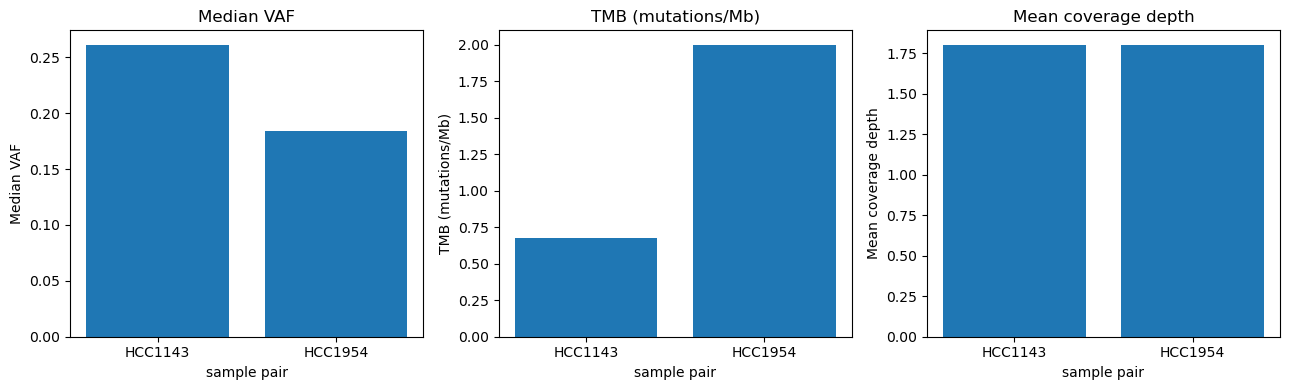

In [14]:
import matplotlib.pyplot as plt

metrics = ["median_VAF", "TMB_per_Mb", "mean_depth"]
titles  = ["Median VAF", "TMB (mutations/Mb)", "Mean coverage depth"]

# One row of three charts, side by side.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(summary["pair"], summary[metric])   # one bar per pair
    ax.set_title(title)
    ax.set_xlabel("sample pair")
    ax.set_ylabel(title)

plt.tight_layout()   # keep the three charts from overlapping
plt.show()


# Containerization with Docker

To make the whole pipeline run identically on any computer, we package it into a Docker image ([Docker](https://www.docker.com/)). The image carries a small Linux system, the conda environment with every tool, and our Snakefiles and configuration. Anyone can then run the exact same analysis without installing anything by hand.

We need two files: an `environment.yml` that lists the tools, and a `Dockerfile` that describes how to build the image. The two cells below write those files.


In [15]:
%%writefile environment.yml
name: cancer_genomics
channels:
  - conda-forge
  - bioconda
dependencies:
  - python=3.10
  - bwa
  - samtools
  - htslib
  - gatk4
  - snakemake-minimal
  - picard
  - fastqc
  - mosdepth
  - pandas
  - matplotlib


Writing environment.yml


In [16]:
%%writefile Dockerfile
# Start from a small Linux image that already includes conda.
FROM continuumio/miniconda3:latest

# Set the working folder inside the container.
WORKDIR /pipeline

# Copy the tool list into the image first (so this slow step is cached and reused).
COPY environment.yml /pipeline/environment.yml

# Build the conda environment from that list, then clean up to keep the image small.
RUN conda env create -f environment.yml && conda clean -a -y

# Put the environment's programs on the PATH so they are found automatically.
ENV PATH=/opt/conda/envs/cancer_genomics/bin:$PATH

# Copy our workflow files into the image.
COPY Snakefile Snakefile_multi config.yaml config_multi.yaml /pipeline/

# By default, run the scaled workflow when the container starts.
# The user can override these arguments on the command line.
ENTRYPOINT ["snakemake"]
CMD ["-s", "Snakefile_multi", "--cores", "4"]


Writing Dockerfile


## The Dockerfile explained line by line

- `FROM continuumio/miniconda3:latest`: start from a ready made Linux image that already has conda installed, so we do not build Linux from scratch ([Docker Hub: miniconda3](https://hub.docker.com/r/continuumio/miniconda3)).
- `WORKDIR /pipeline`: create and move into a folder named `/pipeline` inside the image; later commands run there.
- `COPY environment.yml /pipeline/environment.yml`: copy our tool list into the image. Doing this before copying anything else lets Docker reuse (cache) the slow install step when only other files change.
- `RUN conda env create -f environment.yml && conda clean -a -y`: install all the tools listed in the file, then delete installer leftovers to keep the image smaller.
- `ENV PATH=/opt/conda/envs/cancer_genomics/bin:$PATH`: tell the system where our tools live, so typing `bwa` or `snakemake` just works.
- `COPY Snakefile Snakefile_multi config.yaml config_multi.yaml /pipeline/`: copy the workflow files into the image.
- `ENTRYPOINT ["snakemake"]` and `CMD ["-s", "Snakefile_multi", "--cores", "4"]`: set the default action, which is to launch the scaled pipeline with 4 cores. Anything you type after the image name replaces the `CMD` part.


## Building and running the image

Build the image once. The `.` at the end means "use the Dockerfile in the current folder", and `-t` gives the image a friendly name.


In [ ]:
%%bash
# Build the image and name it "cancer-genomics-pipeline".
docker build -t cancer-genomics-pipeline .


DEPRECATED: The legacy builder is deprecated and will be removed in a future release.
            Install the buildx component to build images with BuildKit:
            https://docs.docker.com/go/buildx/



Then run it. Because the huge data files stay on your machine, we "mount" your project folder into the container with `-v`, so the container can read and write your files. `-w` sets the working folder inside the container to that same mounted location, so all the relative paths in the Snakefiles line up ([Docker run reference](https://docs.docker.com/engine/reference/commandline/run/)).

A note on the folder path in `-v`. In Windows PowerShell you can use the Windows style path shown below. If you are inside a bash shell (WSL2 or Git Bash), write the folder as `/c/Users/chuab/Desktop/cancer_genomics_pipeline_hcc1143_brca` instead.


In [ ]:
%%bash
# Run the pipeline inside the container.
#   -v maps your project folder to /data inside the container (left of the colon = your machine).
#   -w sets /data as the working folder, so relative paths in the Snakefiles resolve correctly.
#   --rm removes the finished container afterwards to keep things tidy.

docker run --rm \
  -v "C:\Users\chuab\Desktop\cancer_genomics_pipeline_hcc1143_brca:/data" \
  -w /data \
  cancer-genomics-pipeline \
  -s Snakefile_multi --cores 4


# Results Summary and Conclusion

## What this notebook accomplished

This notebook built a complete cancer genomics pipeline in plain language, from raw DNA reads to a clean list of somatic mutations, and then to clinically meaningful summary numbers. For the HCC1954 pair we ran the full workflow: quality checking, alignment with BWA-MEM, sorting and indexing with Samtools, duplicate marking with Picard, base quality recalibration, and somatic mutation calling with GATK Mutect2, followed by careful filtering. For the HCC1143 pair we started from pre aligned BAM files and went straight to mutation calling and filtering.

We then automated the whole thing with Snakemake so it runs with a single command, scaled it to process both tumor and normal pairs together, and calculated three key metrics with pandas: Variant Allele Frequency, Tumor Mutational Burden, and exon coverage depth. Finally, we packaged everything into a Docker image so the analysis runs identically on any computer.

## Caveats and honest limitations

- **Cell line data, not fresh patient tumors.** HCC1143 and HCC1954 are laboratory cell lines, which are cleaner and more uniform than real patient samples, so results here are a teaching demonstration rather than clinical findings.
- **Very small sample size.** With only two pairs, the comparisons are illustrations of the method, not statistically meaningful biology.
- **Different starting points.** One pair began as raw FASTQ and the other as aligned BAM. This is a useful teaching contrast, but it also means the two pairs were not processed through identical steps, so direct number to number comparisons should be made with care.
- **Simplified metrics.** The TMB here divides PASS mutations by an assumed exome size, and coverage depth is measured genome wide unless you supply a target exon BED file. Both can be refined with the exact capture kit regions for a clinical grade result.
- **Reference resources.** For the clearest teaching path, BQSR used the gnomAD known sites; adding the standard dbSNP and Mills resources would refine base quality recalibration further ([broad-references/hg38/v0](https://console.cloud.google.com/storage/browser/gcp-public-data--broad-references/hg38/v0)).

## Closing thought

The value of this project is not the two specific cancers, but the reusable, automated, and reproducible system around them. Given any new tumor and normal pair, the same one command workflow, wrapped in the same container, produces the same kind of trustworthy mutation list and summary metrics, which is exactly what good, shareable science looks like.
